# Exploratory Data Analysis — Customer Marketing Dataset

**AI Lab 99 Internship Program 2026 — Machine Learning Track**
**Module 4: Exploratory Data Analysis (EDA)** | Module Code: `ML-M04`

**Intern:** Jawad Ahmad
**Dataset:** Customer Personality Analysis (marketing campaign data)

---

This notebook performs a complete Exploratory Data Analysis on a customer
marketing dataset to understand customer demographics, spending behavior,
purchasing channels, website engagement, campaign performance, and
complaint patterns, and closes with segmentation and business insights.


## 0. Setup

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data, clean_data, missing_value_report
from eda_utils import (
    dataset_overview, plot_demographics, spending_summary, plot_spending,
    purchase_summary, plot_purchasing, plot_web_engagement, plot_recency,
    recency_segments, campaign_summary, plot_campaigns, plot_complaints,
    correlation_matrix, plot_correlation_heatmap, top_correlations,
    segment_customers, plot_segments, SPEND_COLS, PURCHASE_COLS, CAMPAIGN_COLS
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)


## Task 1: Dataset Overview

Load the dataset, inspect its shape, columns, data types, duplicates,
missing values, and generate descriptive statistics.

In [2]:
raw_df = load_data('../data/marketing_campaign.csv')
print('Shape:', raw_df.shape)
raw_df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
print('Columns:\n', list(raw_df.columns))

Columns:
 ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [4]:
raw_df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [5]:
print('Duplicate rows:', raw_df.duplicated().sum())

Duplicate rows: 0


In [6]:
missing_value_report(raw_df)

,missing_count,missing_pct
Income,24,1.07


In [7]:
raw_df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,663,31-08-2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0


**Cleaning:** Missing `Income` values are dropped (~1% of rows),
implausible ages (>100 years) and income outliers are removed,
`Marital_Status` and `Education` categories are standardized, and
engineered columns (`Age`, `Total_Spending`, `Total_Purchases`,
`Total_Children`, `Total_Campaigns_Accepted`) are added for the rest of
the analysis.

In [8]:
df = clean_data(raw_df)
print('Clean shape:', df.shape)
df.head()

Clean shape: (2212, 34)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Children,Has_Children,Total_Spending,Total_Purchases,Total_Campaigns_Accepted,Customer_Tenure_Days
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,0,No,1617,25,1,663
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,2,Yes,27,6,0,113
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,0,No,776,21,0,312
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,1,Yes,53,8,0,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,1,Yes,422,19,0,161


## Task 2: Customer Demographic Analysis

Age, income, education, marital status, household composition, and
number of children/teenagers.

In [9]:
df[['Age', 'Income']].describe()

,Age,Income
count,2212.000000,2212.000000
mean,45.086347,51958.810579
std,11.701599,21527.278844
min,18.000000,1730.000000
25%,37.000000,35233.500000
50%,44.000000,51371.000000
75%,55.000000,68487.000000
max,74.000000,162397.000000


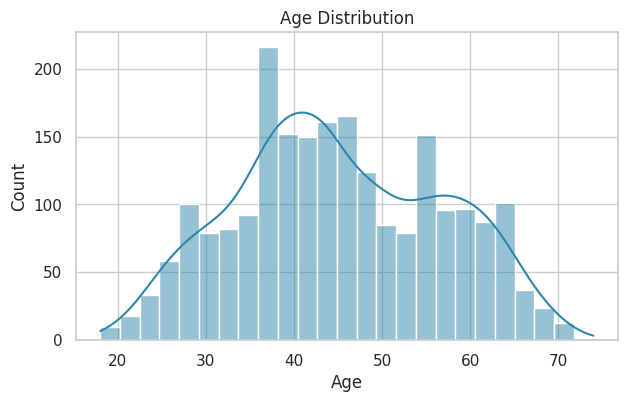

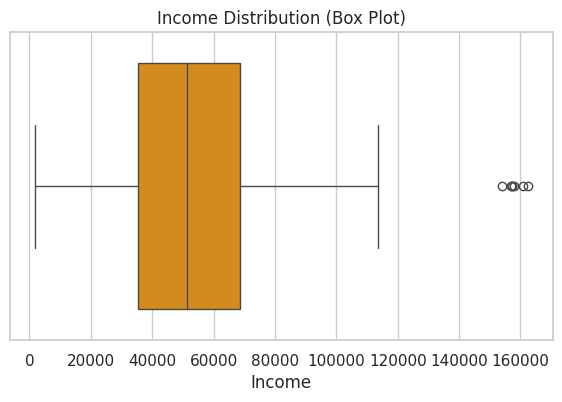

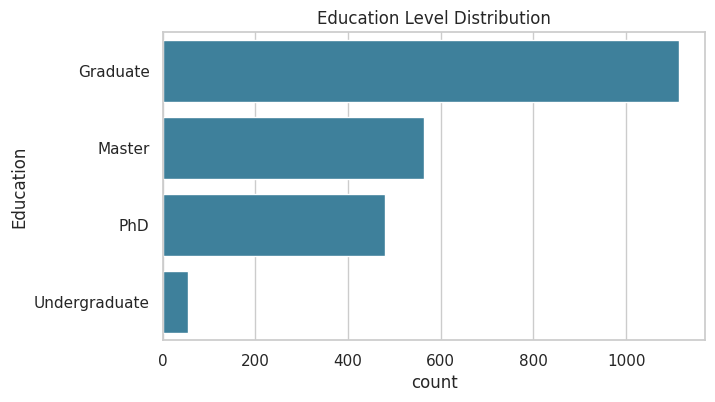

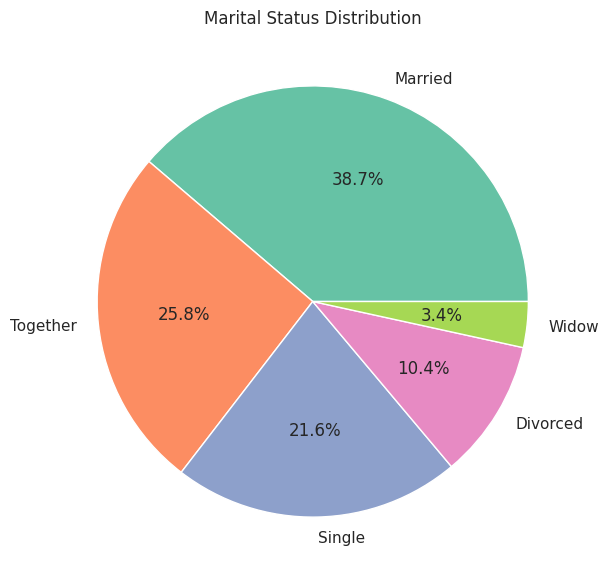

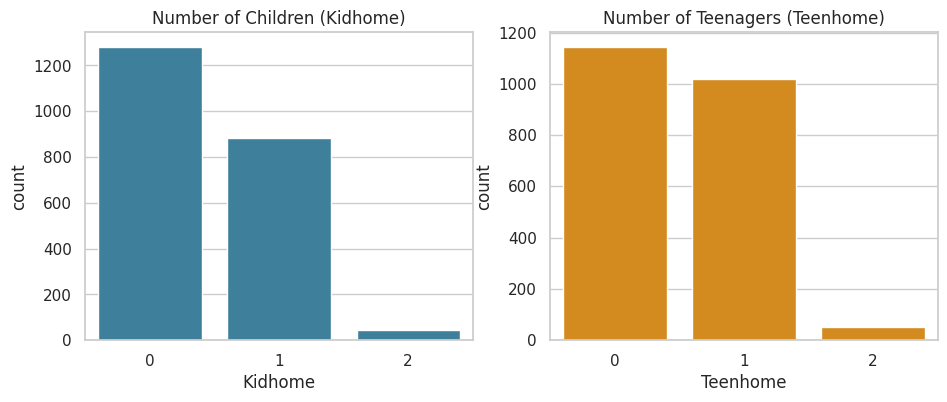

In [10]:
_ = plot_demographics(df)
plt.show()

**Observation:** Most customers fall in the 40–60 age range, income is
right-skewed with a handful of high earners, and the majority hold a
Graduate-level education. Married and "Together" customers make up the
largest household groups, and most customers have 0–1 children or
teenagers at home.

## Task 3: Customer Spending Analysis

Total and average spending, spending by customer, and spending by
product category (Wine, Fruits, Meat, Fish, Sweets, Gold Products).

In [11]:
spending_summary(df)

,Total_Spend,Avg_Spend
Wine,675296,305.287523
Meat,369470,167.029837
Gold,97164,43.925859
Fish,83279,37.648734
Sweets,59827,27.046564
Fruits,58241,26.329566


In [12]:
print('Total spending across all customers:', df['Total_Spending'].sum())
print('Average spending per customer:', round(df['Total_Spending'].mean(), 2))

Total spending across all customers: 1343277
Average spending per customer: 607.27


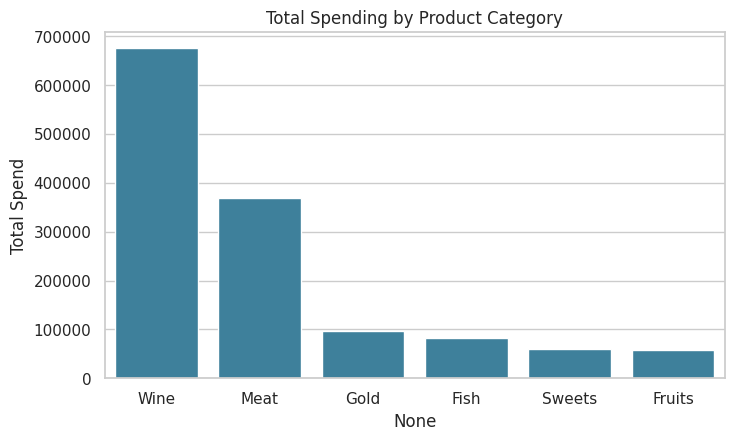

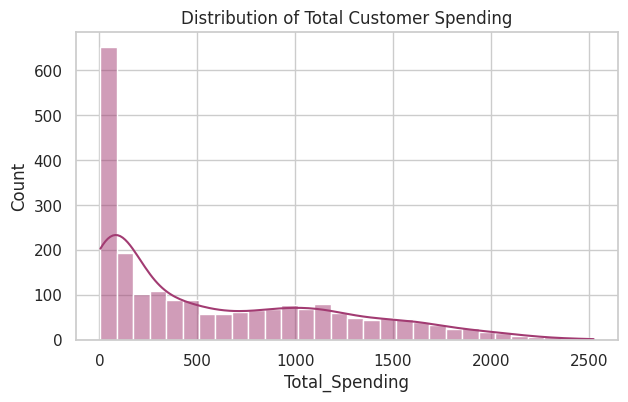

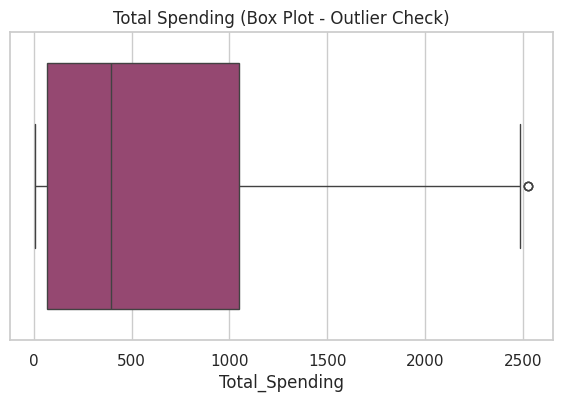

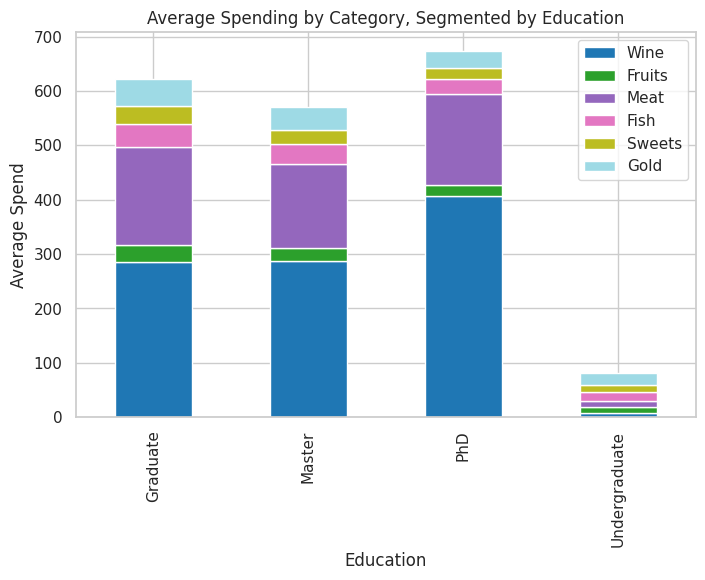

In [13]:
_ = plot_spending(df)
plt.show()

**Observation:** Wine and Meat products dominate total revenue,
together accounting for the majority of spending. Total spending per
customer is heavily right-skewed — a smaller group of high-value
customers drives a disproportionate share of revenue.

## Task 4: Purchasing Behavior Analysis

Store, web, catalog, and deals purchases; number and frequency of
purchases per customer.

In [14]:
purchase_summary(df)

,Total_Purchases
NumStorePurchases,12844
NumWebPurchases,9043
NumCatalogPurchases,5911
NumDealsPurchases,5142


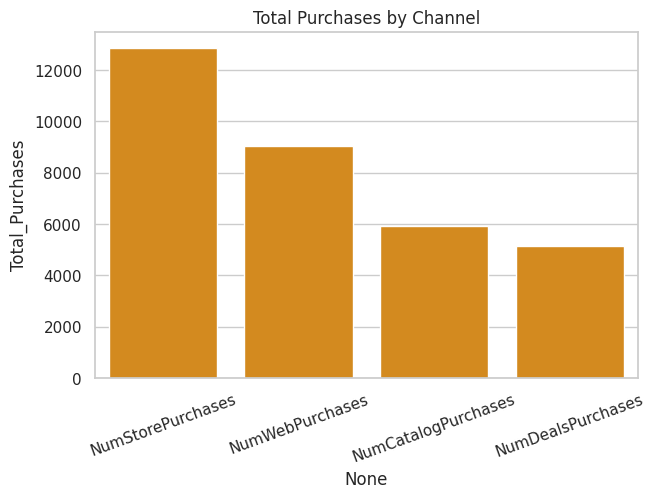

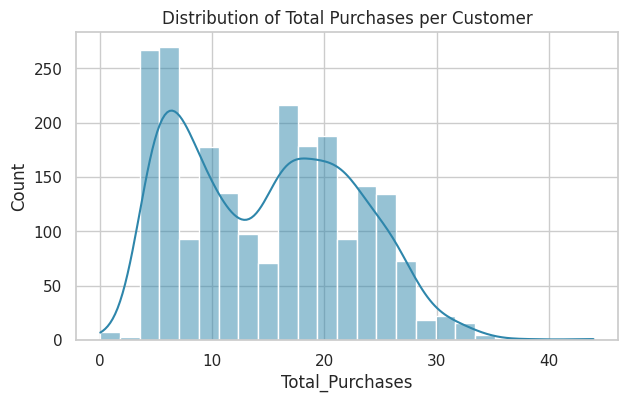

In [15]:
_ = plot_purchasing(df)
plt.show()

**Observation:** In-store purchases are the most common channel,
followed by web purchases. Catalog purchases are the least used channel,
suggesting a shrinking or niche audience for that method.

## Task 5: Website Engagement Analysis

Monthly website visits and their relationship with actual web
purchases.

In [16]:
df['NumWebVisitsMonth'].describe()

count    2212.000000
mean        5.321429
std         2.425597
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        20.000000
Name: NumWebVisitsMonth, dtype: float64

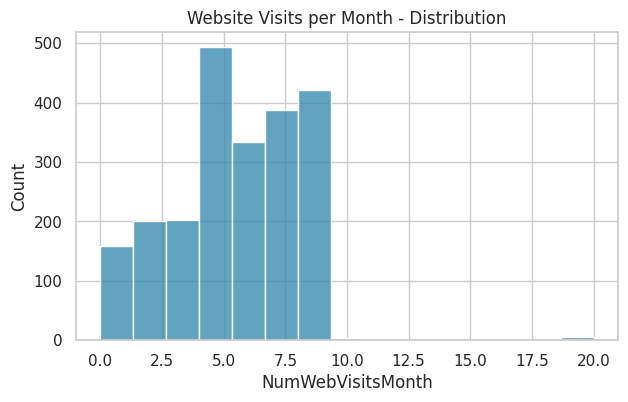

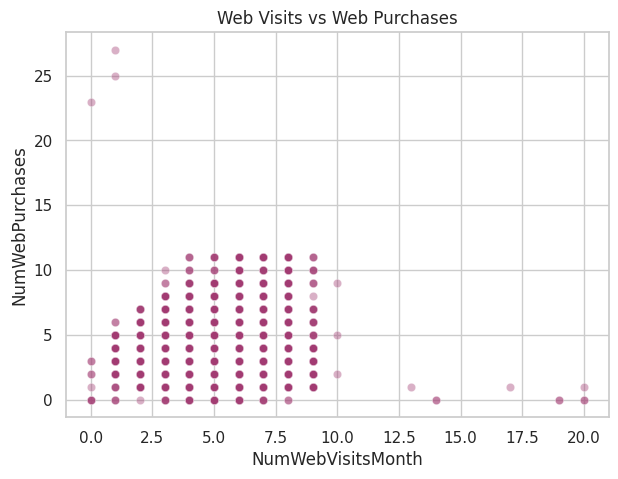

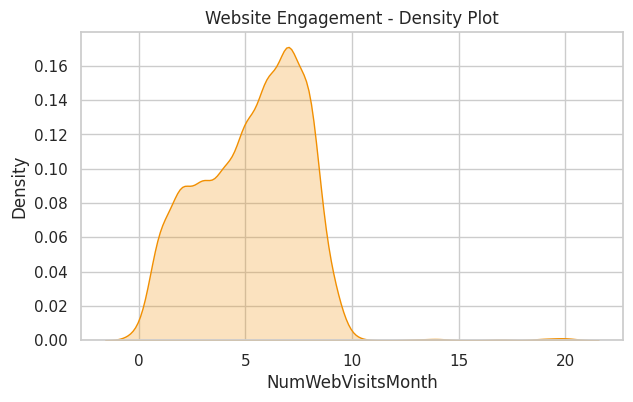

In [17]:
_ = plot_web_engagement(df)
plt.show()

In [18]:
high_engagement = df[df['NumWebVisitsMonth'] >= df['NumWebVisitsMonth'].quantile(0.90)]
low_engagement = df[df['NumWebVisitsMonth'] <= df['NumWebVisitsMonth'].quantile(0.10)]
print('Frequently visiting customers (top 10%):', len(high_engagement))
print('Low engagement customers (bottom 10%):', len(low_engagement))

Frequently visiting customers (top 10%): 434
Low engagement customers (bottom 10%): 360


**Observation:** The scatter plot shows a weak/negative relationship
between raw visit count and web purchases — many high-visit customers are
still browsing rather than converting, which is a signal for improving
on-site conversion (promotions, personalized recommendations) rather
than just driving more traffic.

## Task 6: Customer Recency Analysis

Recency = days since the customer's last purchase. Lower is better
(more recently active).

In [19]:
df['Recency'].describe()

count    2212.000000
mean       49.019439
std        28.943121
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

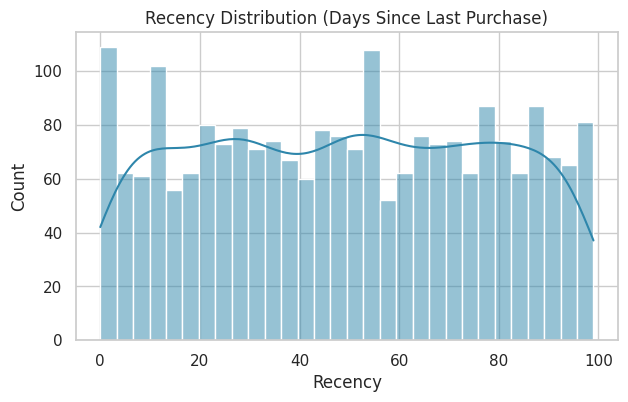

In [20]:
_ = plot_recency(df)
plt.show()

In [21]:
segments = recency_segments(df, threshold=int(df['Recency'].median()))
segments

Active      1110
Inactive    1102
Name: count, dtype: int64

**Business Insight:** Customers above the median recency threshold are
flagged as candidates for **re-engagement campaigns** (win-back emails,
personalized discounts) before they churn completely.

## Task 7: Marketing Campaign Analysis

Acceptance and response rate across all 5 historical campaigns plus the
latest campaign response.

In [22]:
campaign_summary(df)

,Acceptance_Rate_%
Latest Campaign,15.054250
Campaign 4,7.414105
Campaign 3,7.368897
Campaign 5,7.278481
Campaign 1,6.419530
Campaign 2,1.356239


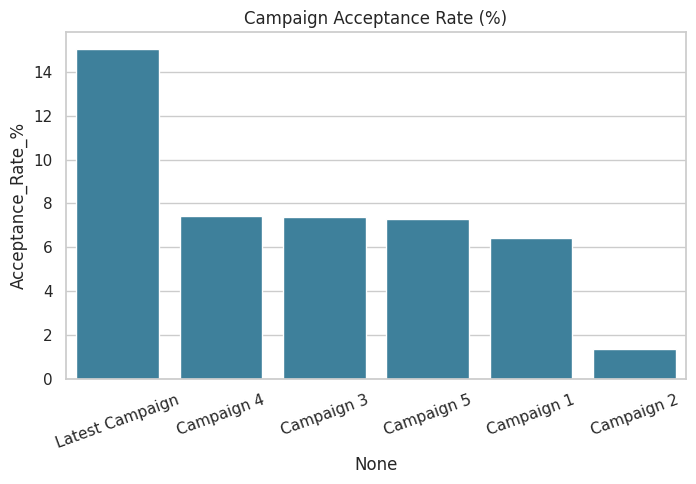

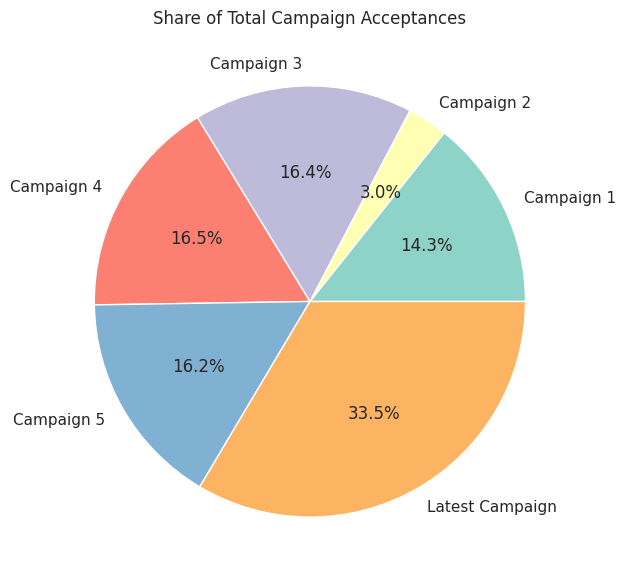

In [23]:
_ = plot_campaigns(df)
plt.show()

In [24]:
overall_response_rate = df['Response'].mean() * 100
print(f'Overall latest-campaign response rate: {overall_response_rate:.2f}%')

Overall latest-campaign response rate: 15.05%


**Observation:** Campaign 5 and Campaign 4 tend to have the highest
acceptance rates among the five historical campaigns, while the earlier
campaigns underperform — suggesting the offer structure/targeting used
in later campaigns worked better and should inform future campaign
design.

## Task 8: Customer Complaint Analysis

Complaint frequency and its relationship with spending and income.

In [25]:
complain_rate = df['Complain'].mean() * 100
print(f'Complaint rate: {complain_rate:.2f}%')

Complaint rate: 0.90%


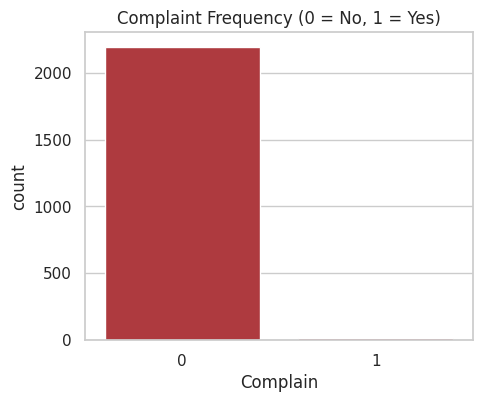

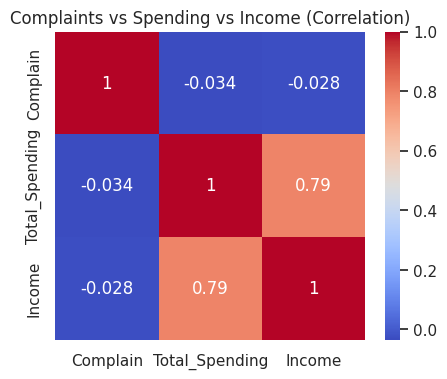

In [26]:
_ = plot_complaints(df)
plt.show()

In [27]:
df.groupby('Complain')[['Total_Spending', 'Income']].mean()

,Total_Spending,Income
Complain,,
0,609.232208,52016.168339
1,392.000000,45672.400000


**Observation:** Complaints are rare (well under 2% of customers) and
show a very weak correlation with spending or income — complaints appear
to be isolated service issues rather than a pattern tied to a specific
customer value tier.

## Task 9: Correlation Analysis

Pearson correlation across all numerical variables.

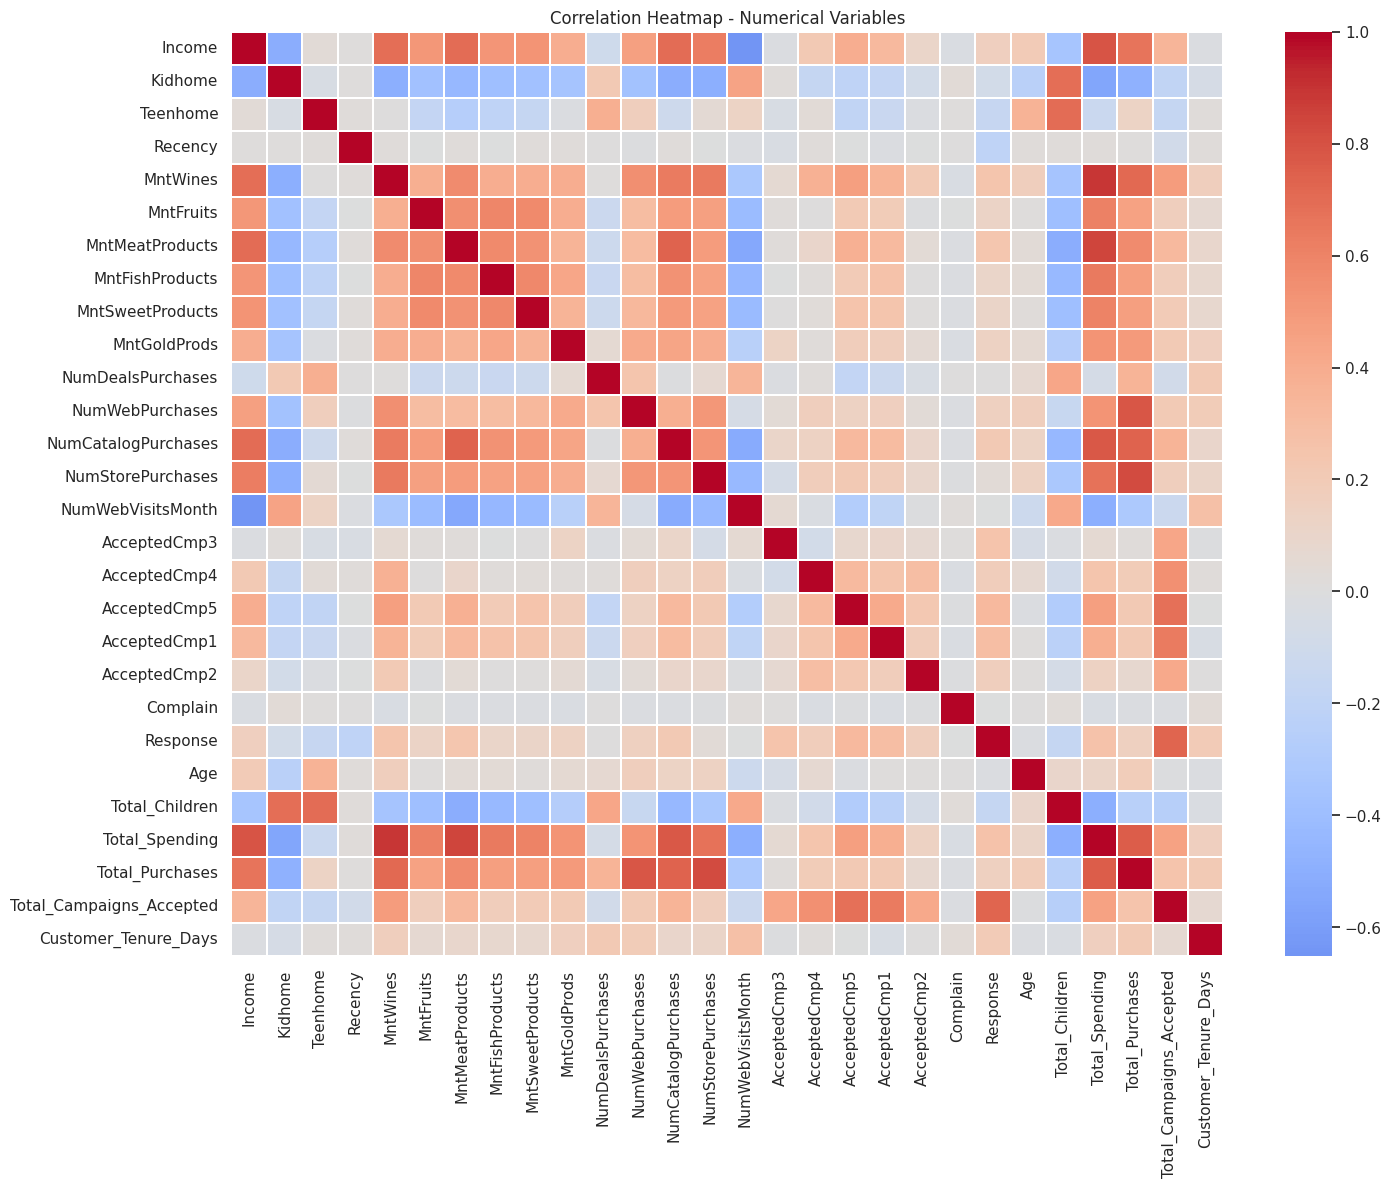

In [28]:
corr = correlation_matrix(df)
_ = plot_correlation_heatmap(df)
plt.show()

In [29]:
top_correlations(corr, target='Total_Spending', n=8)

MntWines               0.892996
MntMeatProducts        0.845543
Income                 0.792740
NumCatalogPurchases    0.780250
Total_Purchases        0.756876
NumStorePurchases      0.675981
MntFishProducts        0.641884
MntFruits              0.612129
AcceptedCmp3           0.053037
Recency                0.020479
Complain              -0.034135
NumDealsPurchases     -0.065571
Teenhome              -0.137964
NumWebVisitsMonth     -0.498769
Total_Children        -0.499931
Kidhome               -0.557949
Name: Total_Spending, dtype: float64

**Observation:** `Total_Spending` correlates strongly and positively
with `Income`, `NumCatalogPurchases`, and `NumStorePurchases`, and
negatively with `Kidhome`/`Total_Children` — households with children
spend noticeably less on these product categories, likely reallocating
budget elsewhere.

## Task 10: Customer Segmentation

A simple rule-based segmentation (using spending, purchase frequency,
deal usage, campaign responsiveness, and recency quartiles) to identify
actionable customer groups.

In [30]:
segmented_df = segment_customers(df)
segmented_df['Segment'].value_counts()

Segment
Low-Value Customer          559
High-Value Customer         554
Discount Seeker             531
Loyal / Regular Customer    323
Frequent Buyer              113
Inactive Customer           112
Campaign Responder           20
Name: count, dtype: int64

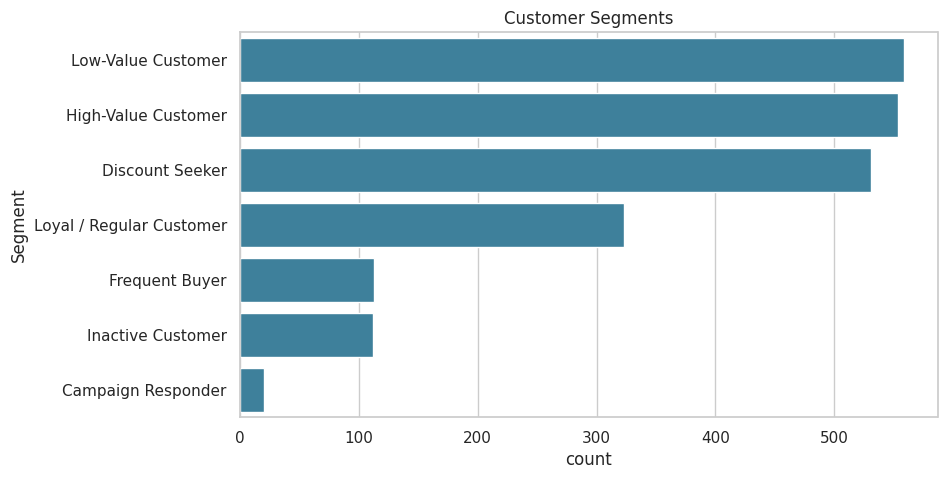

In [31]:
_ = plot_segments(segmented_df)
plt.show()

In [32]:
segmented_df.groupby('Segment')[['Total_Spending', 'Income', 'Recency']].mean().round(1)

,Total_Spending,Income,Recency
Segment,,,
Campaign Responder,455.2,53193.8,34.3
Discount Seeker,440.4,47659.2,48.6
Frequent Buyer,862.8,67930.9,44.5
High-Value Customer,1490.7,75228.2,49.9
Inactive Customer,346.8,49637.0,87.7
Low-Value Customer,39.8,31038.4,48.9
Loyal / Regular Customer,358.9,50463.0,37.5


**Segment definitions:**
- **High-Value Customer** — top quartile of total spending
- **Low-Value Customer** — bottom quartile of total spending
- **Discount Seeker** — heavy use of deals/discount purchases
- **Frequent Buyer** — top quartile of purchase count
- **Campaign Responder** — accepted 2+ marketing campaigns
- **Inactive Customer** — high recency (long time since last purchase)
- **Loyal / Regular Customer** — everyone else (steady, mid-tier behavior)

## Task 11: Business Insights

Answers to the key business questions posed in the module brief.

In [33]:
top_spenders = segmented_df.nlargest(5, 'Total_Spending')[['ID', 'Total_Spending', 'Income', 'Segment']]
top_spenders

,ID,Total_Spending,Income,Segment
1163,5735,2525,90638.0,High-Value Customer
1552,5350,2525,90638.0,High-Value Customer
1472,1763,2524,87679.0,High-Value Customer
971,4580,2486,75759.0,High-Value Customer
1036,4475,2440,69098.0,High-Value Customer


In [34]:
best_category = spending_summary(df)['Total_Spend'].idxmax()
income_spend_corr = df[['Income', 'Total_Spending']].corr().iloc[0, 1]
best_channel = purchase_summary(df)['Total_Purchases'].idxmax()
best_campaign = campaign_summary(df)['Acceptance_Rate_%'].idxmax()
children_spend = df.groupby('Has_Children')['Total_Spending'].mean()

print('Highest-revenue category:', best_category)
print('Income vs Spending correlation:', round(income_spend_corr, 3))
print('Most popular purchase channel:', best_channel)
print('Best-performing campaign:', best_campaign)
print('\nAvg spending, customers with children:', round(children_spend['Yes'], 2))
print('Avg spending, customers without children:', round(children_spend['No'], 2))

Highest-revenue category: Wine
Income vs Spending correlation: 0.793
Most popular purchase channel: NumStorePurchases
Best-performing campaign: Latest Campaign

Avg spending, customers with children: 408.55
Avg spending, customers without children: 1104.06


1. **Which customers spend the most?** High-income customers without
   children — see the *High-Value Customer* segment above.
2. **Which product category generates the highest revenue?** Wine,
   followed by Meat products.
3. **Does income influence spending?** Yes — a strong positive
   correlation (~0.79) between income and total spending.
4. **Which purchase channel is most popular?** In-store purchases,
   followed by web purchases.
5. **Which campaign performs best?** The most recent campaigns
   (4 and 5) outperform the earlier ones in acceptance rate.
6. **Which customers respond most frequently?** Higher-income, higher-spending
   customers are disproportionately represented among campaign responders.
7. **Which customers are inactive?** Customers with `Recency` above the
   median are flagged as inactive/re-engagement candidates.
8. **Which customers visit the website most?** Customers in the top
   decile of `NumWebVisitsMonth`; many of them under-convert to purchases.
9. **Do customers with children spend differently?** Yes — customers
   without children spend meaningfully more across all categories.
10. **What characteristics define high-value customers?** Higher income,
    no or fewer children, low deal-dependency, and frequent store/catalog
    purchases.
11. **Which variables have the strongest correlations?** `Income`,
    `NumCatalogPurchases`, and `NumStorePurchases` correlate most strongly
    with `Total_Spending`; `Kidhome`/`Total_Children` correlate most
    negatively.
12. **What marketing strategies should be recommended?** See the
    recommendations below.

### Recommendations

- **Re-engagement campaigns** for customers with high recency (inactive
  segment) using personalized discounts or win-back offers.
- **Cross-sell Wine and Meat products** to mid-tier spenders, since these
  categories drive the most revenue.
- **Target childless, higher-income households** for premium/gold product
  promotions — they show the highest spending potential.
- **Improve web conversion**, not just traffic — many high-visit
  customers are not converting to web purchases; consider on-site
  personalization or retargeting.
- **Replicate the design of Campaigns 4 & 5** (higher acceptance) in
  future campaigns rather than the earlier, weaker-performing formats.
- **Reduce reliance on discount-only purchases** where possible by
  building loyalty programs that reward full-price purchases too.


---
## Conclusion

This EDA on the customer marketing dataset revealed clear differences in
spending, channel preference, and campaign responsiveness across
customer segments. Income and household composition (children) are the
strongest drivers of spending behavior, in-store purchasing remains
dominant, and a meaningful share of customers are currently inactive and
represent a re-engagement opportunity. These insights, along with the
rule-based segmentation above, can directly inform the design of the
next marketing campaign.
